# Bayesian (Linear) Regression

![bayesfun](images/bayesfun.jpg)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, norm
from scipy.stats import gamma as gamma_dist, poisson
from scipy.optimize import minimize
from numpy.linalg import inv, slogdet
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

rng = np.random.default_rng(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

---
## 1  Bayesian Estimation & Conjugate Priors

### 1.1  Setting

Given $N$ i.i.d. observations $\underline{x} = x_1,\ldots,x_N$ from a model $p(x\mid\theta)$, the posterior over parameters is

$$p(\theta\mid\underline{x}) = \frac{p(\underline{x}\mid\theta)\,p(\theta)}{p(\underline{x})}$$

where $p(\underline{x}) = \int p(\underline{x}\mid\theta)\,p(\theta)\,d\theta$ is the marginal likelihood (evidence).

Instead of a point estimate $\theta_{\text{MAP}}$, Bayesian inference gives the full posterior distribution $p(\theta\mid\underline{x})$ , which we then use to define the predictive distribution

$$p(x\mid\underline{x}) = \int p(x\mid\theta)\,p(\theta\mid\underline{x})\,d\theta$$

### 1.2  Conjugate Priors

The prior $p(\theta)$ and likelihood $p(\underline{x}\mid\theta)$ are conjugate if the posterior $p(\theta\mid\underline{x})$ has the same functional form as the prior.

### 1.3  Beta–Bernoulli Example

Suppose $x_i \in \{0,1\}$ and $p(x_i\mid\theta) = \text{Bernoulli}(\theta)$. After observing $k$ ones in $N$ trials the log-posterior is

$$\log p(\theta\mid\underline{x}) = (k+\alpha-1)\log\theta + (N-k+\beta-1)\log(1-\theta) + C$$

then $p(\theta \mid \underline{x}) = \text{Beta}(k+\alpha,\, N-k+\beta)$. The predictive probability is

$$p(x=1\mid\underline{x}) = \int_0^1 p(x=1\mid\theta)\,p(\theta\mid\underline{x})\,d\theta = \mathbb{E}[\theta \mid \underline{x}]=\frac{k+\alpha}{N+\alpha+\beta}$$

In [2]:
theta_grid = np.linspace(0.01, 0.99, 500)
alpha0, beta0 = 3.0, 2.0
N_max = 200

coin_flips = rng.integers(0, 2, size=N_max)
N_vals = list(range(0, N_max+1, 10))

fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot([], [], 'b', lw=2)
vline = ax.axvline(x=0.5, color='r', lw=1, linestyle='--', label='True theta=0.5')
title = ax.set_title('')
ax.set_xlim(0, 1); ax.set_ylim(0, 20)
ax.set_xlabel('theta'); ax.set_ylabel('p(theta | data)')
ax.legend(fontsize=9)

def init():
    line.set_data([], [])
    return line,

def update(N):
    k = coin_flips[:N].sum() if N > 0 else 0
    alpha_N = alpha0 + k
    beta_N  = beta0  + N - k
    pdf = beta_dist.pdf(theta_grid, alpha_N, beta_N)
    line.set_data(theta_grid, pdf)
    pred = (k + alpha0) / (N + alpha0 + beta0)
    ax.set_title(f'N={N}, k={k}   Predictive p(x=1)={pred:.2f}')
    return line,

ani = FuncAnimation(fig, update, frames=N_vals, init_func=init,
                    interval=400, blit=False, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

---
## 2  Linear Regression

### 2.1  Model

We have pairs $(x_i, y_i)$, $i=1,\ldots,N$ and assume

$$p(y\mid x,\theta) = \mathcal{N}\!\left(y\,\big|\,f(x,w),\,\beta^{-1}\right), \qquad f(x,w) = \sum_{j=0}^{M-1} w_j\,\phi_j(x) = w^\top\phi(x)$$

where $\phi_j$ are basis functions.

$$
\phi_{\text{GRBF}}(x, x_\text{center}) = \exp( - \gamma \| x - x_\text{center}\|^2_2)
$$



### 2.2  Maximum Likelihood

Maximizing $\log p(\underline{y}\mid\underline{x},\theta)$ is equivalent to minimising the sum-of-squares $\| y - w^\top\Phi \| ^ 2 _ 2$

$$E_D(w) = \frac{1}{2}\sum_{i=1}^N \bigl(y_i - w^\top\phi(x_i)\bigr)^2$$

Setting $\nabla_w E_D = 0$ gives the closed-form solution

$$w_{\text{ML}} = (\Phi^\top\Phi)^{-1}\Phi^\top\underline{y}$$

where $\Phi_{ij} = \phi_j(x_i)$ is the design matrix.

### 2.3 Adding regularization term
To avoid overfitting one adds a regularization term to $E_D(w)$ : $\frac{\lambda}{2}\|w\|_2^2$

The ridge regression yelds to the following solution

$$w_{\text{Ridge}} = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top\underline{y}$$

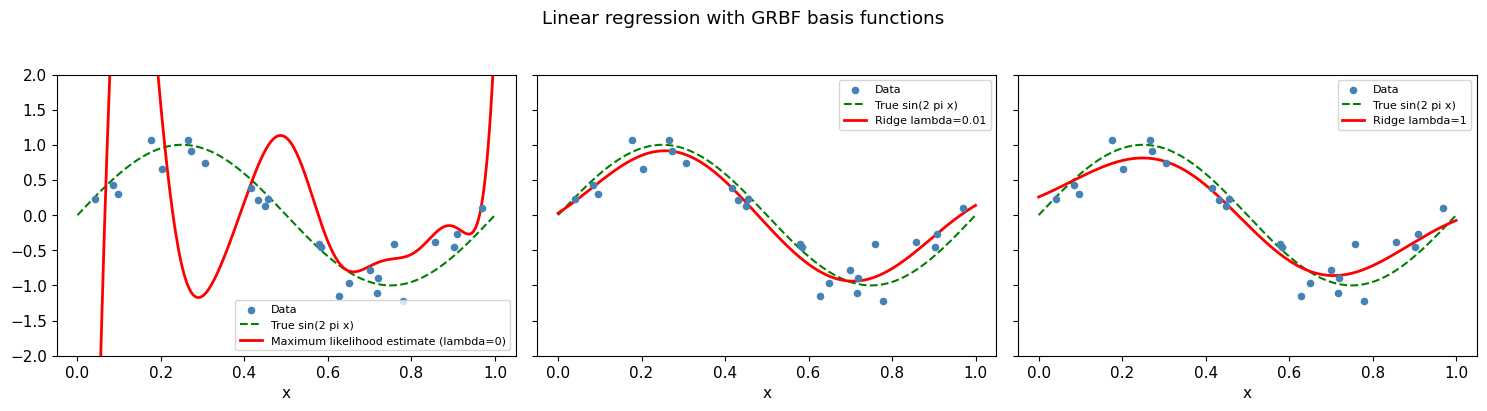

In [3]:
def rbf_basis(x, centers, width):
    """
    Design matrix with Gaussian RBF basis functions.
    x       : (N,) input points
    centers : (M,) RBF centres
    width   : scalar bandwidth
    Returns : (N, M) design matrix
    """
    return np.exp(-0.5 * ((x[:, None] - centers[None, :]) / width) ** 2)


# Synthetic dataset: y = sin(2 pi x) + noise
N           = 25
beta_true   = 25.0
x_train     = rng.uniform(0, 1, N)
y_train     = np.sin(2 * np.pi * x_train) + rng.normal(0, 1/np.sqrt(beta_true), N)

x_plot = np.linspace(0, 1, 300)
y_true  = np.sin(2 * np.pi * x_plot)

# Basis functions
M       = 20
centers = np.linspace(0, 1, M)
width   = 0.2

Phi_train = rbf_basis(x_train, centers, width)   # (N, M)
Phi_plot  = rbf_basis(x_plot,  centers, width)   # (300, M)

def ridge_weights(Phi, y, lam):
    M = Phi.shape[1]
    return inv(Phi.T @ Phi + lam * np.eye(M)) @ Phi.T @ y

lambdas = [0.0, 0.01, 1.0]
labels  = ['Maximum likelihood estimate (lambda=0)', 'Ridge lambda=0.01', 'Ridge lambda=1']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, lam, lbl in zip(axes, lambdas, labels):
    if lam == 0:
        w = inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train
    else:
        w = ridge_weights(Phi_train, y_train, lam)
    y_pred = Phi_plot @ w
    ax.scatter(x_train, y_train, s=20, color='steelblue', zorder=5, label='Data')
    ax.plot(x_plot, y_true, 'g--', lw=1.5, label='True sin(2 pi x)')
    ax.plot(x_plot, y_pred, 'r', lw=2, label=lbl)
    ax.set_xlabel('x')
    ax.legend(fontsize=8); ax.set_ylim(-2, 2)

fig.suptitle('Linear regression with GRBF basis functions', y=1.02)
plt.tight_layout()
plt.show()

---
## 3  Bayesian Linear Regression

### 3.1  Prior

We place a Gaussian prior over the weights:

$$
p(w\mid\alpha) = \mathcal{N}(w\mid 0,\,\alpha^{-1}I)
$$

where $\alpha$ is a hyper-parameter controlling the prior precision.



### 3.2  Posterior

Because the likelihood is Gaussian in $w$ and so is the prior, the posterior is also Gaussian. This is derived by recognising that $\log p(w\mid\cdot)$ is a quadratic form in $w$.

$$p(w\mid\underline{x},\underline{y},\alpha,\beta) = \mathcal{N}(w\mid m_N, S_N)$$

where

$$
S_N^{-1} = \alpha I_M + \beta\,\Phi^\top\Phi \in \mathbb{R}^{M,M} , \qquad m_N = \beta\,S_N\,\Phi^\top\underline{y} \in \mathbb{R}^M
$$




In [33]:
def compute_posterior(Phi, y, alpha, beta):
    """
    Compute Gaussian posterior N(w | m_N, S_N).
    """
    M = Phi.shape[1]
    S_N_inv = alpha * np.eye(M) + beta * Phi.T @ Phi
    S_N = inv(S_N_inv)
    m_N = beta * S_N @ Phi.T @ y
    return m_N, S_N


alpha = 100.0   # prior precision
beta  = 10.0  # noise precision
# how alpha affects the posterior and the predictive distribution in Bayesian linear regression?##

m_N, S_N = compute_posterior(Phi_train, y_train, alpha, beta)

N_frames = list(range(0, N + 1))
n_samples =10

fig, ax = plt.subplots(figsize=(7, 4))
scatter = ax.scatter([], [], s=25, color='steelblue', zorder=5)
ax.plot(x_plot, y_true, 'g--', lw=1.5, label='True')
sample_lines = [ax.plot([], [], 'r', alpha=0.5, lw=1)[0] for _ in range(n_samples)]
ax.set_xlim(0, 1); ax.set_ylim(-2, 2)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9, loc='upper right')
ttl = ax.set_title('')

def update_seq(n):
    if n == 0:
        m_n = np.zeros(M)
        S_n = (1/alpha) * np.eye(M)
        scatter.set_offsets(np.empty((0, 2)))
    else:
        idx = np.argsort(x_train)[:n]
        m_n, S_n = compute_posterior(Phi_train[idx], y_train[idx], alpha, beta)
        scatter.set_offsets(np.column_stack([x_train[idx], y_train[idx]]))
    samples = np.random.default_rng(0).multivariate_normal(m_n, S_n, size=n_samples)
    for line, w_s in zip(sample_lines, samples):
        line.set_data(x_plot, Phi_plot @ w_s)
    ttl.set_text(f'N={n} observations: w1, ..., w{n_samples} samples from posterior')
    return [scatter, ttl] + sample_lines

ani = FuncAnimation(fig, update_seq, frames=N_frames,
                    interval=200, blit=False, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

### 3.3 Effect of $\alpha$ in Bayesian Linear Regression

Recall
$$
S_N^{-1} = \alpha I + \beta\Phi^\top\Phi, \qquad m_N = \beta S_N\Phi^\top y.
$$

The prior is $p(w\mid\alpha)=\mathcal{N}(0,\alpha^{-1}I)$, so $\alpha$ is the prior precision (inverse variance).

- **Large $\alpha$ (strong prior, small prior variance):**
  - Prior pushes weights toward zero.
  - Posterior covariance $S_N$ becomes smaller (weights are more concentrated around the mean).
  - Posterior mean $m_N$ is shrunk more strongly toward zero.
  - Predictive mean becomes smoother / less flexible (more underfitting risk).
  - Predictive variance often increases away from dense data regions due to stronger regularization.

- **Small $\alpha$ (weak prior, large prior variance):**
  - Prior is diffuse, so data dominates more.
  - Less shrinkage of weights; posterior mean can fit data more closely.
  - Posterior covariance tends to be larger when data is limited (more parameter uncertainty).
  - Predictive mean is more flexible (can overfit if too small and data is noisy).

For a test input $x^*$ with feature vector $\phi(x^*)$,
$$
p(y^*\mid x^*,D)=\mathcal{N}\!\left(\phi(x^*)^\top m_N,\;\frac{1}{\beta}+\phi(x^*)^\top S_N\phi(x^*)\right).
$$

So $\alpha$ influences prediction through both:
- the **mean term** via $m_N$ (amount of shrinkage), and
- the **epistemic uncertainty term** $\phi(x^*)^\top S_N\phi(x^*)$.

As $N$ grows, data dominates the prior and the influence of $\alpha$ decreases.

---
## 4  Predictive Distribution

Given a new input $x^*$, we average over all weight vectors under the posterior:

$$p(y^*\mid x^*,\underline{x},\underline{y},\alpha,\beta) = \int p(y^*\mid x^*,w,\beta)\,p(w\mid\underline{x},\underline{y},\alpha,\beta)\,dw$$

$$p(y^*\mid x^*,\ldots) = \mathcal{N}\!\left(y^*\,\big|\,m_N^\top\phi(x^*),\;\sigma_N^2(x^*)\right)$$

$$\sigma_N^2(x^*) = \tfrac{1}{\beta} + \phi(x^*)^\top S_N\,\phi(x^*) $$

As $N\to\infty$ the epistemic term vanishes and $\sigma_N^2 \to 1/\beta$.

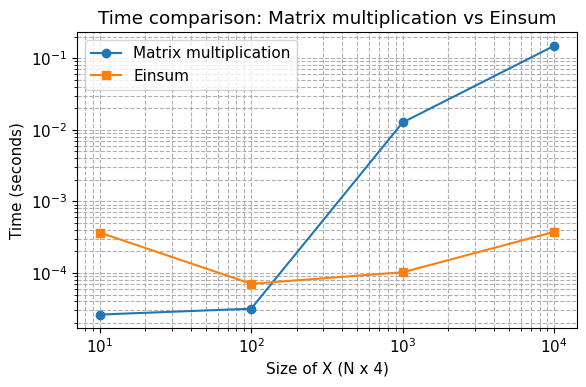

In [31]:
import time

### A computational trick

times_matmul = []
times_einsum = []
sizes = [10, 100, 1000, 10000]
for s in sizes:
    X = np.random.multivariate_normal(np.zeros(4), np.eye(4), size=s)
    S = np.random.multivariate_normal(np.zeros(4), np.eye(4), size=4) 

    #Computing with usual matrix multiplication: X^T @ S @ X
    start_time = time.time()
    result = X @ S @ X.T
    end_time = time.time()
    times_matmul.append(end_time - start_time)

    # Computing with einsum
    start_time = time.time()
    result_einsum = np.einsum('ij,jk,ki->i', X, S, X.T)
    end_time = time.time()
    times_einsum.append(end_time - start_time)


plt.figure(figsize=(6, 4))
plt.plot(sizes, times_matmul, 'o-', label='Matrix multiplication')
plt.plot(sizes, times_einsum, 's-', label='Einsum')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Size of X (N x 4)'); plt.ylabel('Time (seconds)')
plt.title('Time comparison: Matrix multiplication vs Einsum')
plt.legend(); plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [34]:
def predictive_distribution(Phi_star, m_N, S_N, beta):
    """
    Returns predictive mean and variance at test points.
    """
    mu      = Phi_star @ m_N
    sigma2 = 1/beta + np.einsum('ij,jk,ik->i', Phi_star, S_N, Phi_star) # (N_test, M) @ (M, M) @ (N_test, M).T -> (N_test,)
    return mu, sigma2

N_frames = list(range(1, N + 1))

fig, ax = plt.subplots(figsize=(7, 4))
scatter = ax.scatter([], [], s=25, color='steelblue', zorder=5)
ax.plot(x_plot, y_true, 'g--', lw=1.5, label='True sin(2 pi x)')
mean_line, = ax.plot([], [], 'r', lw=2, label='Predictive mean')
fill = [ax.fill_between(x_plot, np.zeros(len(x_plot)), np.zeros(len(x_plot)), alpha=0.25, color='red', label='std')]
ax.set_xlim(0, 1)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=9)
ttl = ax.set_title('')

def update_pred(n):
    global fill
    idx = np.arange(n)
    m_n, S_n = compute_posterior(Phi_train[idx], y_train[idx], alpha, beta)
    mu_pred, var_pred = predictive_distribution(Phi_plot, m_n, S_n, beta)
    std_pred = np.sqrt(var_pred)

    scatter.set_offsets(np.column_stack([x_train[idx], y_train[idx]]))
    mean_line.set_data(x_plot, mu_pred)

    # Redraw fill_between each frame
    fill[0].remove()
    fill[0] = ax.fill_between(x_plot,
                               mu_pred - std_pred,
                               mu_pred + std_pred,
                               alpha=0.25, color='red')
    ttl.set_text(f'N={n} observations: predictive mean and standard deviation')
    return [scatter, mean_line, ttl]

ani = FuncAnimation(fig, update_pred, frames=N_frames,
                    interval=200, blit=False, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

---
## 5  Model Evidence & Hyperparameter Optimisation

### 5.1  Marginal Likelihood

The hyper-parameters $\alpha, \beta$ are chosen by maximising the **marginal likelihood** (model evidence)

$$
p(\underline{y}\mid\underline{x},\alpha,\beta) = \int p(\underline{y}\mid\underline{x},w,\beta)\,p(w\mid\alpha)\,dw = \frac{p(\underline{y}\mid\underline{x},w,\alpha,\beta)\,p(w\mid\alpha)}{p(w \mid \underline{y} , \underline{x},\alpha,\beta)}
$$ 

Taking the logarithm we obtain

$$\log p(\underline{y}\mid\underline{x},\alpha,\beta) = \frac{M}{2}\log\alpha + \frac{N}{2}\log\beta - E(m_N) - \frac{1}{2}\log|S_N^{-1}| - \frac{N}{2}\log 2\pi$$

where $E(m_N) = \frac{\beta}{2}\|\underline{y}-\Phi m_N\|^2 + \frac{\alpha}{2}m_N^\top m_N$.



### 5.2  Fixed-Point Algorithm

Setting $\nabla_{\alpha,\beta}\log p = 0$ yields fixed-point update equations. Let $\lambda_i$ be the eigenvalues of $\beta\Phi^\top\Phi$ and define the **effective number of parameters**

$$\gamma = \sum_{i=0}^{M-1} \frac{\lambda_i}{\alpha + \lambda_i}$$

Then the updates are

$$\alpha \leftarrow \frac{\gamma}{m_N^\top m_N}, \qquad \frac{1}{\beta} \leftarrow \frac{1}{N-\gamma}\sum_{n=1}^N \bigl(y_n - m_N^\top\phi(x_n)\bigr)^2$$

Optimised hyperparameters:  alpha = 5.3064,  beta = 22.6469


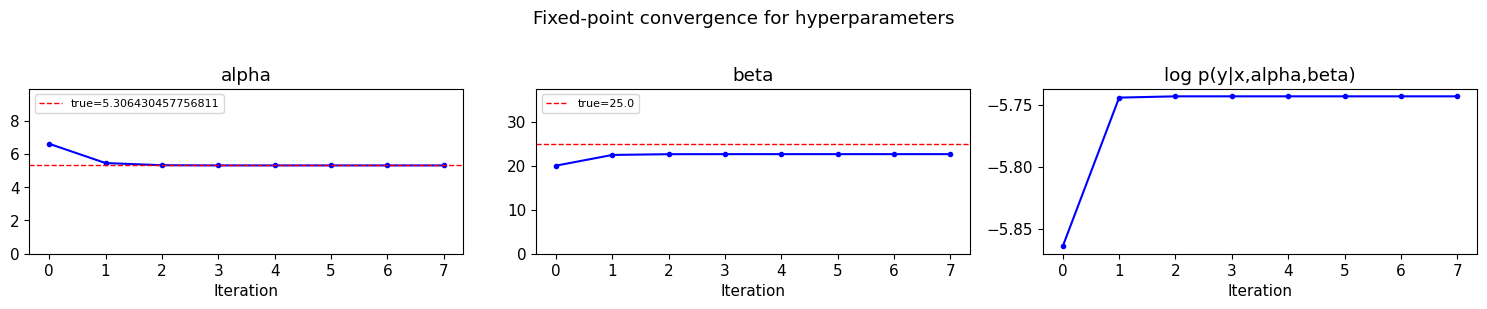

<Figure size 640x480 with 0 Axes>

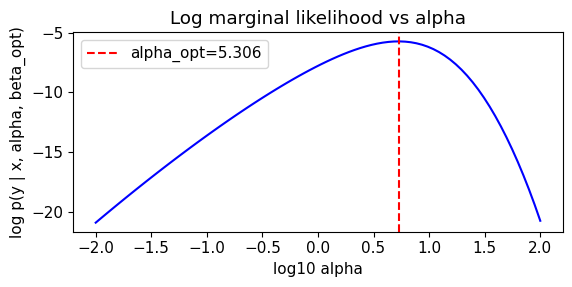

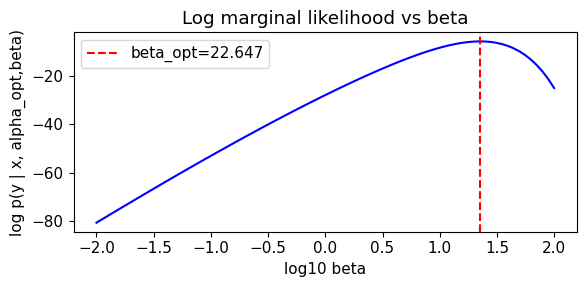

In [10]:
def log_marginal_likelihood(alpha, beta, Phi, y):
    N, M = Phi.shape
    m_N, S_N = compute_posterior(Phi, y, alpha, beta)
    S_N_inv = alpha * np.eye(M) + beta * Phi.T @ Phi
    E_mN = (beta/2) * np.sum((y - Phi @ m_N)**2) + (alpha/2) * m_N @ m_N
    sign, logdet = slogdet(S_N_inv)
    return (M/2)*np.log(alpha) + (N/2)*np.log(beta) - E_mN - 0.5*logdet - (N/2)*np.log(2*np.pi)


def fixed_point_hyperparams(Phi, y, max_iter=200, tol=1e-6):
    N, M = Phi.shape
    alpha, beta = 1, 1
    eigenvalues = np.linalg.eigvalsh(Phi.T @ Phi)  # eigenvalues of Phi^T Phi
    history = []
    for _ in range(max_iter):
        lam = beta * eigenvalues                    # eigenvalues of beta Phi^T Phi
        gamma = np.sum(lam / (alpha + lam))
        m_N, _ = compute_posterior(Phi, y, alpha, beta)
        alpha_new = gamma / (m_N @ m_N)
        residuals = y - Phi @ m_N
        beta_new  = (N - gamma) / np.sum(residuals**2)
        history.append((alpha_new, beta_new,
                        log_marginal_likelihood(alpha_new, beta_new, Phi, y)))
        if abs(alpha_new - alpha) + abs(beta_new - beta) < tol:
            break
        alpha, beta = alpha_new, beta_new
    return alpha, beta, np.array(history)


alpha_opt, beta_opt, hist = fixed_point_hyperparams(Phi_train, y_train)
print(f'Optimised hyperparameters:  alpha = {alpha_opt:.4f},  beta = {beta_opt:.4f}')

# Plot convergence
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, col, lbl, ref in zip(axes, range(3),
                              ['alpha', 'beta', 'log p(y|x,alpha,beta)'],
                              [alpha_opt, beta_true, None]):
    ax.plot(hist[:, col], 'b-o', ms=3)
    if ref is not None:
        ax.axhline(ref, color='r', lw=1, linestyle='--', label=f'true={ref}')
        ax.legend(fontsize=8, loc='upper left')
        ax.set_ylim(0, max(hist[:, col].max(), ref)*1.5)
    ax.set_xlabel('Iteration'); ax.set_title(lbl)

fig.suptitle('Fixed-point convergence for hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

# Plot log marginal likelihood vs log alpha
log_alphas = np.linspace(-2, 2, 80)
lml_vals   = [log_marginal_likelihood(10**la, beta_opt, Phi_train, y_train)
              for la in log_alphas]

# plot marignal likelihood vs beta
log_betas = np.linspace(-2, 2, 80)
lml_vals_beta = [log_marginal_likelihood(alpha_opt, 10**lb, Phi_train, y_train) for lb in log_betas]
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 3))
plt.plot(log_alphas, lml_vals, 'b')
plt.axvline(np.log10(alpha_opt), color='r', lw=1.5, linestyle='--', label=f'alpha_opt={alpha_opt:.3f}')
plt.xlabel('log10 alpha'); plt.ylabel('log p(y | x, alpha, beta_opt)')
plt.title('Log marginal likelihood vs alpha')
plt.legend(); plt.tight_layout(); plt.show()


plt.figure(figsize=(6, 3))
plt.plot(log_betas, lml_vals_beta, 'b')
plt.axvline(np.log10(beta_opt), color='r', lw=1.5
            , linestyle='--', label=f'beta_opt={beta_opt:.3f}')
plt.xlabel('log10 beta'); plt.ylabel('log p(y | x, alpha_opt,beta)')
plt.title('Log marginal likelihood vs beta')
plt.legend(); plt.tight_layout(); plt.show()


---
## 6  Model Comparison

Suppose we have two models $\mathbb{M}_1, \mathbb{M}_2$ (e.g. different numbers of basis functions, the first model is nested in the second). Using equal priors $p(\mathbb{M}_1)=p(\mathbb{M}_2)$, the posterior model ratio is

$$\frac{p(D\mid\mathbb{M}_1)}{p(D\mid\mathbb{M}_2)}
$$

where $p(D\mid\mathbb{M}_j) = \int p(D\mid\theta,\mathbb{M}_j)\,p(\theta\mid\mathbb{M}_j)\,d\theta$ is the marginal likelihood of model $j$.

By a Kullback–Leibler argument, the Bayes Factor is on average $> 1$ when $\mathbb{M}_1$ generated the data, recovering Occam's Razor: a simpler model is preferred in absence of sufficient evidence for complexity.

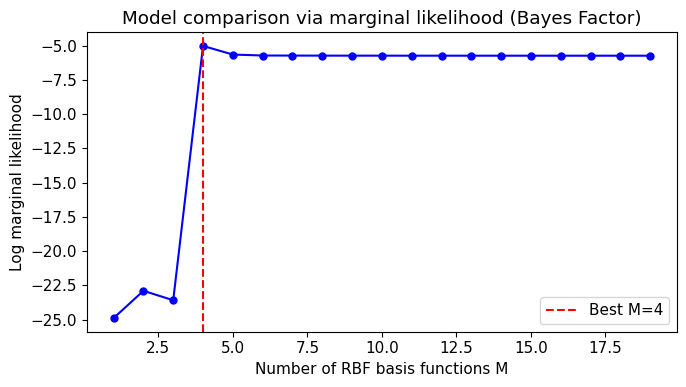

In [11]:
# Compare models with different numbers of RBF centres
M_values = list(range(1, 20))
lml_by_M = []

for M_test in M_values:
    c = np.linspace(0, 1, M_test)
    Ph = rbf_basis(x_train, c, width)
    a_opt, b_opt, _ = fixed_point_hyperparams(Ph, y_train)
    lml_by_M.append(log_marginal_likelihood(a_opt, b_opt, Ph, y_train))

best_M = M_values[np.argmax(lml_by_M)]

plt.figure(figsize=(7, 4))
plt.plot(M_values, lml_by_M, 'b-o', ms=5)
plt.axvline(best_M, color='r', lw=1.5, linestyle='--', label=f'Best M={best_M}')
plt.xlabel('Number of RBF basis functions M')
plt.ylabel('Log marginal likelihood')
plt.title('Model comparison via marginal likelihood (Bayes Factor)')
plt.legend(); plt.tight_layout(); plt.show()


---
## 7  Laplace Approximation

When the posterior $p(\theta\mid D)$ is not analytically tractable (e.g. logistic regression, non-conjugate models), we approximate it with a Gaussian centred at the MAP estimate.

**Algorithm:**
1. Find $\theta_{\text{MAP}} = \arg\max_\theta \log p(\theta\mid D)$
2. Compute the Hessian of the negative log-posterior at $\theta_{\text{MAP}}$:
   $$A = -\nabla^2 \log p(\theta\mid D)\big|_{\theta=\theta_{\text{MAP}}}$$
3. Approximate: $q(\theta) = \mathcal{N}(\theta\mid\theta_{\text{MAP}},\, A^{-1})$

This follows from a second-order Taylor expansion of $\log p(\theta\mid D)$ around $\theta_{\text{MAP}}$:

$$\log p(\theta\mid D) \approx \log p(\theta_{\text{MAP}}\mid D) - \tfrac{1}{2}(\theta-\theta_{\text{MAP}})^\top A\,(\theta-\theta_{\text{MAP}})$$

Below we demonstrate this on a **1D Gamma-Poisson** posterior (intentionally non-Gaussian) to show how well the approximation works.

In [12]:
# True posterior is Gamma, but we pretend we don't know and apply Laplace.

# Data: Poisson counts
lambda_true = 5.0
obs = rng.poisson(lambda_true, size=10)

print(f'Observed counts: {obs}')

Observed counts: [4 7 3 7 7 4 4 5 5 3]


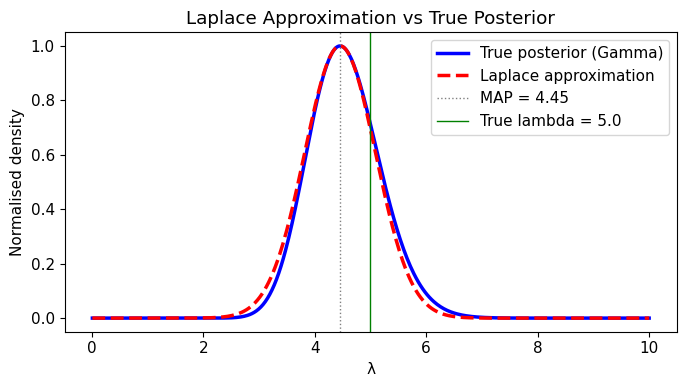

In [16]:
# Prior: Gamma(a0, b0)  (shape, rate)
# The mean is shape/rate

a0, b0 = 1.0, 1.0

# True posterior functional: Gamma(a0 + sum(obs), b0 + N)
a_post = a0 + obs.sum()
b_post = b0 + len(obs)

lam_grid = np.linspace(0.01, 10, 500)
log_posterior = (gamma_dist.logpdf(lam_grid, a_post, scale=1/b_post))
true_posterior = np.exp(log_posterior)
true_posterior /= true_posterior.max()

# Laplace approximation
def neg_log_post(lam):
    lam = float(np.squeeze(lam))
    if lam <= 0: return 1e10
    log_lik  = poisson.logpmf(obs, lam).sum()
    log_prior = gamma_dist.logpdf(lam, a0, scale=1/b0)
    return -(log_lik + log_prior)

result  = minimize(neg_log_post, x0=[2.0], method='Nelder-Mead')
lam_MAP = result.x[0]

# Numerical second derivative (Hessian)
h = 1e-4
A = (neg_log_post([lam_MAP + h]) - 2*neg_log_post([lam_MAP]) + neg_log_post([lam_MAP - h])) / h**2
sigma_laplace = 1.0 / np.sqrt(A)

laplace_approx = norm.pdf(lam_grid, lam_MAP, sigma_laplace)
laplace_approx /= laplace_approx.max()

plt.figure(figsize=(7, 4))
plt.plot(lam_grid, true_posterior,  'b',  lw=2.5, label='True posterior (Gamma)')
plt.plot(lam_grid, laplace_approx,  'r--', lw=2.5, label='Laplace approximation')
plt.axvline(lam_MAP, color='gray', lw=1, linestyle=':', label=f'MAP = {lam_MAP:.2f}')
plt.axvline(lambda_true, color='green', lw=1, linestyle='-', label=f'True lambda = {lambda_true}')
plt.xlabel('λ'); plt.ylabel('Normalised density')
plt.title('Laplace Approximation vs True Posterior')
plt.legend()
plt.tight_layout()
plt.savefig('laplace_poisson_gamma.png', dpi=150)

---
## 8  Bayesian Information Criterion (BIC)

The BIC is a cheap approximation to the log marginal likelihood derived from the Laplace approximation.

Starting from the Laplace approximation of the marginal likelihood:

$$\log p(D\mid\mathbb{M}) \approx \log p(D\mid\theta_{\text{MAP}}) + \log p(\theta_{\text{MAP}}) + \frac{M}{2}\log(2\pi) - \frac{1}{2}\log|A|$$

Dropping constants, the prior term and by applying some approximations one obtains the BIC:

$$\text{BIC} = \log p(D\mid\theta_{\text{MAP}},\mathbb{M}) - \frac{M}{2}\log N$$

A higher BIC indicates a better model (more evidence). The penalty $\frac{M}{2}\log N$ grows with both $M$ (model complexity) and $N$ (dataset size), implementing an automatic Occam's Razor.

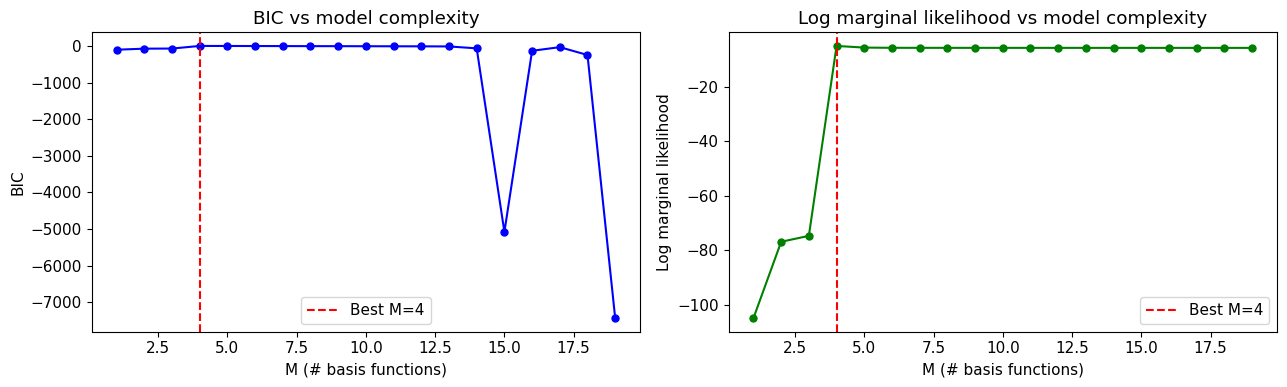

In [36]:
def compute_bic(Phi, y, beta):
    """
    BIC for a linear-Gaussian model.
    Uses the MLE weights (theta_MAP under flat prior) and Gaussian log-likelihood.
    """
    N, M = Phi.shape
    w_mle = inv(Phi.T @ Phi) @ Phi.T @ y
    residuals = y - Phi @ w_mle
    log_lik = (-beta/2) * np.sum(residuals**2) + (N/2)*np.log(beta/(2*np.pi))
    bic = log_lik - (M/2) * np.log(N)
    return bic


# Compute BIC for models of varying complexity
bic_by_M  = []
lml_by_M2 = []

for M_test in M_values:
    c  = np.linspace(0, 1, M_test)
    Ph = rbf_basis(x_train, c, width)
    # BIC uses MLE; for fair comparison fix beta at the true value
    bic_by_M.append(compute_bic(Ph, y_train, beta_true))
    # Marginal likelihood (recomputed with fixed beta for a like-for-like comparison)
    a_opt, _, _ = fixed_point_hyperparams(Ph, y_train)
    lml_by_M2.append(log_marginal_likelihood(a_opt, beta_true, Ph, y_train))

best_M_bic = M_values[np.argmax(bic_by_M)]
best_M_lml = M_values[np.argmax(lml_by_M2)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(M_values, bic_by_M, 'b-o', ms=5)
axes[0].axvline(best_M_bic, color='r', lw=1.5, linestyle='--', label=f'Best M={best_M_bic}')
axes[0].set_xlabel('M (# basis functions)')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC vs model complexity')
axes[0].legend()

axes[1].plot(M_values, lml_by_M2, 'g-o', ms=5)
axes[1].axvline(best_M_lml, color='r', lw=1.5, linestyle='--', label=f'Best M={best_M_lml}')
axes[1].set_xlabel('M (# basis functions)')
axes[1].set_ylabel('Log marginal likelihood')
axes[1].set_title('Log marginal likelihood vs model complexity')
axes[1].legend()

plt.tight_layout()
plt.show()


In [28]:
# how alpha affects the posterior and the predictive distribution in Bayesian linear regression.


In [ ]:
# empirically verify that $\sigma_{N}^2 \righarrow \frac{1}{\beta}$ as $N \rightarrow \infty$ in Bayesian linear regression.

In [30]:
# when log marginal likelihood and BIC disagree?